# Logistic Regression: PD vs CN Classification

Train and evaluate logistic regression models on CYMO linguistic features  
using two different feature sets (mRMR vs old approach) and compare performance.

### Important: subject-level splitting
Each subject has many utterances. If we split randomly by row, the same subject's  
utterances could appear in both train and test sets — the model would learn  
subject-specific patterns and give falsely high accuracy.  
Instead, we split by **subject**: all utterances from a subject go to the same split.

---

In [28]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CHANGE THESE PATHS                                        ║
# ╚══════════════════════════════════════════════════════════════╝

CYMO_CSV    = '../ParkCeleb/ann.cymo_parkceleb.csv'            # full CYMO output
META_CSV    = '../ParkCeleb/cymo_parkceleb_metadata.csv'       # metadata with group/subject
MRMR_FEATS  = './mrmr_selected_features.csv'       # mRMR feature list
OLD_FEATS   = './cymo_final_selected_features.csv'  # old approach feature list

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay)
from sklearn.model_selection import GroupShuffleSplit
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
})
print('Imports OK')

Imports OK


---
## 1 — Load data and feature lists

In [30]:
# ============================================================
# 1.1  Load CYMO results and merge with metadata
# ============================================================
cymo = pd.read_csv(CYMO_CSV)
meta = pd.read_csv(META_CSV)

tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]

df = cymo.merge(
    meta[[meta_tid, 'group', 'subject']].drop_duplicates(),
    left_on=tid_col, right_on=meta_tid, how='inner'
)
df['label'] = (df['group'] == 'PD').astype(int)

# Convert all feature columns to numeric
all_feature_cols = [c for c in cymo.columns if c != tid_col]
for col in all_feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Total data: {len(df)} utterances from {df["subject"].nunique()} subjects')
print(f'  CN: {(df["label"]==0).sum()} utterances, {df[df["label"]==0]["subject"].nunique()} subjects')
print(f'  PD: {(df["label"]==1).sum()} utterances, {df[df["label"]==1]["subject"].nunique()} subjects')

Total data: 149546 utterances from 100 subjects
  CN: 82826 utterances, 60 subjects
  PD: 66720 utterances, 40 subjects


In [31]:
# ============================================================
# 1.2  Load feature lists
# ============================================================
mrmr_feat_df = pd.read_csv(MRMR_FEATS)
mrmr_features = mrmr_feat_df['feature'].tolist()

old_feat_df = pd.read_csv(OLD_FEATS)
old_features = old_feat_df['feature'].tolist()

# Verify all features exist in the data
mrmr_features = [f for f in mrmr_features if f in df.columns]
old_features = [f for f in old_features if f in df.columns]

print(f'mRMR features: {len(mrmr_features)}')
print(f'Old features:  {len(old_features)}')

shared = set(mrmr_features) & set(old_features)
print(f'Shared:        {len(shared)}')

mRMR features: 25
Old features:  25
Shared:        2


---
## 2 — Subject-level train / validation / test split (70 / 20 / 10)

All utterances from a given subject go to the **same** split.  
This prevents data leakage — the model never sees test subjects during training.

In [32]:
# ============================================================
# 2.  Subject-level stratified split
# ============================================================
np.random.seed(42)

# Get unique subjects with their group labels
subject_labels = df.groupby('subject')['label'].first().reset_index()
subject_labels.columns = ['subject', 'label']

# Separate CN and PD subjects for stratified splitting
cn_subjects = subject_labels[subject_labels['label'] == 0]['subject'].values.copy()
pd_subjects = subject_labels[subject_labels['label'] == 1]['subject'].values.copy()

np.random.shuffle(cn_subjects)
np.random.shuffle(pd_subjects)

def stratified_split(subjects, train_frac=0.7, val_frac=0.2, test_frac=0.1):
    """Split subject array into train/val/test with given fractions."""
    n = len(subjects)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    # Remaining goes to test
    train = subjects[:n_train]
    val = subjects[n_train:n_train + n_val]
    test = subjects[n_train + n_val:]
    return train, val, test

cn_train, cn_val, cn_test = stratified_split(cn_subjects)
pd_train, pd_val, pd_test = stratified_split(pd_subjects)

train_subjects = np.concatenate([cn_train, pd_train])
val_subjects = np.concatenate([cn_val, pd_val])
test_subjects = np.concatenate([cn_test, pd_test])

# Assign each utterance to its split
df['split'] = 'unassigned'
df.loc[df['subject'].isin(train_subjects), 'split'] = 'train'
df.loc[df['subject'].isin(val_subjects), 'split'] = 'val'
df.loc[df['subject'].isin(test_subjects), 'split'] = 'test'

train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'val'].copy()
test_df = df[df['split'] == 'test'].copy()

print('Subject-Level Split (70 / 20 / 10)')
print('=' * 65)
print(f'{"":<8s} {"Subjects":>10s} {"Utterances":>12s} {"CN subj":>10s} {"PD subj":>10s} {"CN utt":>10s} {"PD utt":>10s}')
print('─' * 65)
for name, sdf, subjs in [('Train', train_df, train_subjects),
                          ('Val', val_df, val_subjects),
                          ('Test', test_df, test_subjects)]:
    n_subj = len(subjs)
    n_utt = len(sdf)
    cn_s = sdf[sdf['label']==0]['subject'].nunique()
    pd_s = sdf[sdf['label']==1]['subject'].nunique()
    cn_u = (sdf['label']==0).sum()
    pd_u = (sdf['label']==1).sum()
    print(f'{name:<8s} {n_subj:>10d} {n_utt:>12d} {cn_s:>10d} {pd_s:>10d} {cn_u:>10d} {pd_u:>10d}')

# Verify no subject leakage
assert len(set(train_subjects) & set(val_subjects)) == 0, 'Leakage: train/val overlap!'
assert len(set(train_subjects) & set(test_subjects)) == 0, 'Leakage: train/test overlap!'
assert len(set(val_subjects) & set(test_subjects)) == 0, 'Leakage: val/test overlap!'
print('\n✓ No subject leakage between splits.')

Subject-Level Split (70 / 20 / 10)
           Subjects   Utterances    CN subj    PD subj     CN utt     PD utt
─────────────────────────────────────────────────────────────────
Train            70       106467         42         28      61729      44738
Val              20        26881         12          8      13697      13184
Test             10        16198          6          4       7400       8798

✓ No subject leakage between splits.


---
## 3 — Train logistic regression models

In [33]:
# ============================================================
# 3.  Helper function to prepare data and train
# ============================================================

def prepare_data(train_df, val_df, test_df, features):
    """
    Prepare feature matrices and labels.
    Fills NaN with training set median, then standardises (zero mean, unit variance).
    """
    X_train = train_df[features].copy()
    X_val = val_df[features].copy()
    X_test = test_df[features].copy()
    
    y_train = train_df['label'].values
    y_val = val_df['label'].values
    y_test = test_df['label'].values
    
    # Fill NaN with training set median
    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_val = X_val.fillna(medians)
    X_test = X_test.fillna(medians)
    
    # Standardise using training set statistics
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, scaler


def train_and_evaluate(X_train, X_val, X_test, y_train, y_val, y_test,
                       features, model_name):
    """
    Train logistic regression with class weighting and evaluate.
    """
    # Train with balanced class weights to handle CN/PD imbalance
    model = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        C=1.0,           # regularisation strength (default)
        random_state=42,
    )
    model.fit(X_train, y_train)
    
    # Predictions
    results = {}
    for split_name, X, y in [('Train', X_train, y_train),
                              ('Val', X_val, y_val),
                              ('Test', X_test, y_test)]:
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]
        
        results[split_name] = {
            'accuracy': accuracy_score(y, y_pred),
            'f1': f1_score(y, y_pred),
            'precision': precision_score(y, y_pred),
            'recall': recall_score(y, y_pred),       # sensitivity
            'specificity': recall_score(y, y_pred, pos_label=0),
            'roc_auc': roc_auc_score(y, y_prob),
            'y_true': y,
            'y_pred': y_pred,
            'y_prob': y_prob,
        }
    
    return model, results

print('Helper functions ready.')

Helper functions ready.


In [34]:
# ============================================================
# 3.1  Train model with mRMR features
# ============================================================
print('Training Model 1: Logistic Regression with mRMR features')
print('=' * 60)

X_tr_m, X_va_m, X_te_m, y_tr, y_va, y_te, scaler_mrmr = \
    prepare_data(train_df, val_df, test_df, mrmr_features)

model_mrmr, results_mrmr = train_and_evaluate(
    X_tr_m, X_va_m, X_te_m, y_tr, y_va, y_te,
    mrmr_features, 'mRMR'
)

# Save model
joblib.dump({'model': model_mrmr, 'scaler': scaler_mrmr, 'features': mrmr_features},
            'logreg_mrmr.joblib')

print(f'\n{"Split":<8s} {"Accuracy":>10s} {"F1":>8s} {"Precision":>10s} {"Recall":>8s} {"Specificity":>12s} {"AUC":>8s}')
print('─' * 62)
for split_name in ['Train', 'Val', 'Test']:
    r = results_mrmr[split_name]
    print(f'{split_name:<8s} {r["accuracy"]:>10.3f} {r["f1"]:>8.3f} {r["precision"]:>10.3f} '
          f'{r["recall"]:>8.3f} {r["specificity"]:>12.3f} {r["roc_auc"]:>8.3f}')

print(f'\nSaved: logreg_mrmr.joblib')

Training Model 1: Logistic Regression with mRMR features

Split      Accuracy       F1  Precision   Recall  Specificity      AUC
──────────────────────────────────────────────────────────────
Train         0.580    0.557      0.500    0.627        0.546    0.631
Val           0.564    0.556      0.555    0.557        0.571    0.580
Test          0.500    0.522      0.542    0.502        0.496    0.523

Saved: logreg_mrmr.joblib


In [35]:
# ============================================================
# 3.2  Train model with old features
# ============================================================
print('Training Model 2: Logistic Regression with old features')
print('=' * 60)

X_tr_o, X_va_o, X_te_o, _, _, _, scaler_old = \
    prepare_data(train_df, val_df, test_df, old_features)

model_old, results_old = train_and_evaluate(
    X_tr_o, X_va_o, X_te_o, y_tr, y_va, y_te,
    old_features, 'Old'
)

# Save model
joblib.dump({'model': model_old, 'scaler': scaler_old, 'features': old_features},
            'logreg_old.joblib')

print(f'\n{"Split":<8s} {"Accuracy":>10s} {"F1":>8s} {"Precision":>10s} {"Recall":>8s} {"Specificity":>12s} {"AUC":>8s}')
print('─' * 62)
for split_name in ['Train', 'Val', 'Test']:
    r = results_old[split_name]
    print(f'{split_name:<8s} {r["accuracy"]:>10.3f} {r["f1"]:>8.3f} {r["precision"]:>10.3f} '
          f'{r["recall"]:>8.3f} {r["specificity"]:>12.3f} {r["roc_auc"]:>8.3f}')

print(f'\nSaved: logreg_old.joblib')

Training Model 2: Logistic Regression with old features

Split      Accuracy       F1  Precision   Recall  Specificity      AUC
──────────────────────────────────────────────────────────────
Train         0.560    0.556      0.483    0.655        0.492    0.614
Val           0.551    0.571      0.537    0.609        0.495    0.567
Test          0.493    0.536      0.533    0.539        0.439    0.503

Saved: logreg_old.joblib


---
## 4 — Side-by-side comparison

In [36]:
# ============================================================
# 4.1  Comparison table
# ============================================================
print('MODEL COMPARISON')
print('=' * 75)
print(f'{"":<8s} {"":>12s}   {"mRMR Features":>15s}   {"Old Features":>15s}   {"Δ":>8s}')
print('─' * 75)

for split_name in ['Val', 'Test']:
    rm = results_mrmr[split_name]
    ro = results_old[split_name]
    print(f'  {split_name}')
    for metric in ['accuracy', 'f1', 'precision', 'recall', 'specificity', 'roc_auc']:
        vm = rm[metric]
        vo = ro[metric]
        delta = vm - vo
        arrow = '↑' if delta > 0.005 else '↓' if delta < -0.005 else '≈'
        print(f'    {metric:<14s} {vm:>15.3f}   {vo:>15.3f}   {delta:>+7.3f} {arrow}')
    print()

MODEL COMPARISON
                          mRMR Features      Old Features          Δ
───────────────────────────────────────────────────────────────────────────
  Val
    accuracy                 0.564             0.551    +0.013 ↑
    f1                       0.556             0.571    -0.014 ↓
    precision                0.555             0.537    +0.018 ↑
    recall                   0.557             0.609    -0.052 ↓
    specificity              0.571             0.495    +0.076 ↑
    roc_auc                  0.580             0.567    +0.013 ↑

  Test
    accuracy                 0.500             0.493    +0.007 ↑
    f1                       0.522             0.536    -0.014 ↓
    precision                0.542             0.533    +0.010 ↑
    recall                   0.502             0.539    -0.037 ↓
    specificity              0.496             0.439    +0.058 ↑
    roc_auc                  0.523             0.503    +0.020 ↑



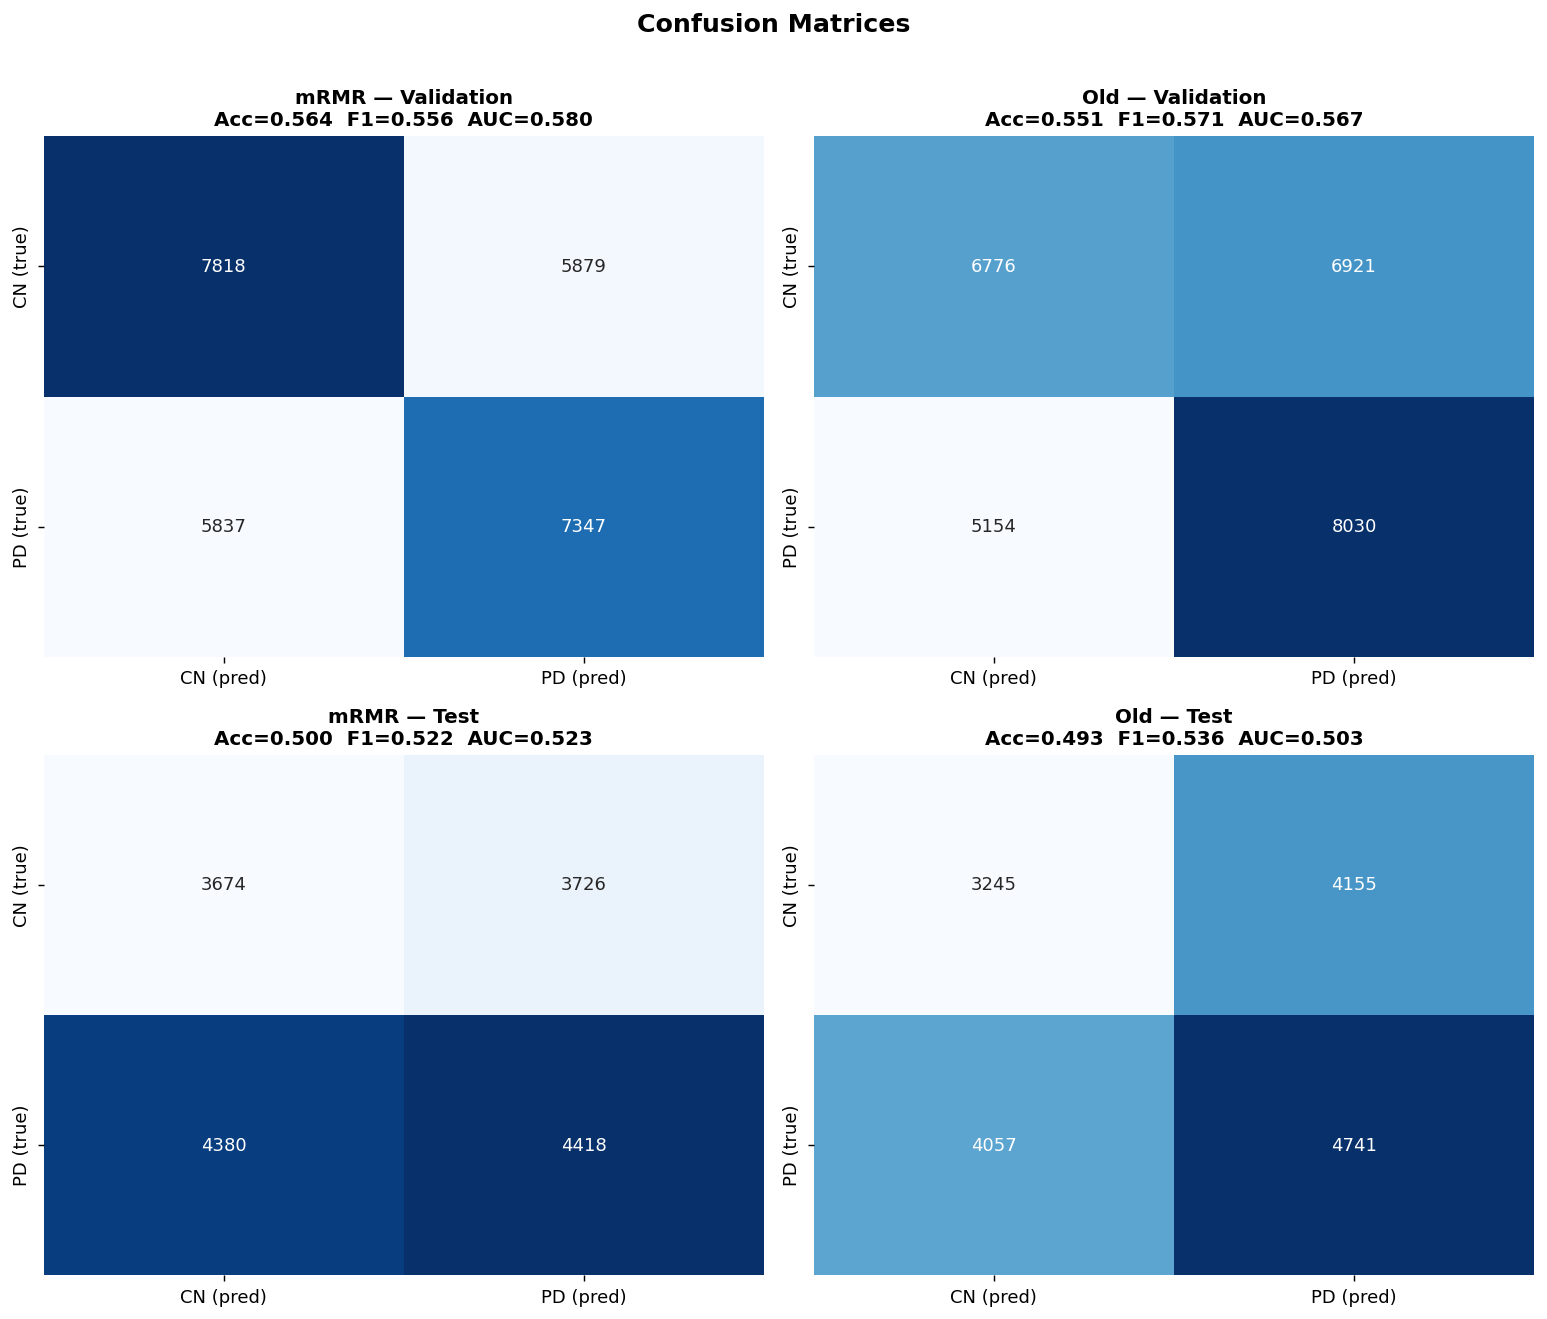

In [37]:
# ============================================================
# 4.2  Confusion matrices
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

configs = [
    (axes[0, 0], results_mrmr, 'Val', 'mRMR — Validation'),
    (axes[0, 1], results_old, 'Val', 'Old — Validation'),
    (axes[1, 0], results_mrmr, 'Test', 'mRMR — Test'),
    (axes[1, 1], results_old, 'Test', 'Old — Test'),
]

for ax, results, split, title in configs:
    r = results[split]
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['CN (pred)', 'PD (pred)'],
                yticklabels=['CN (true)', 'PD (true)'],
                cbar=False)
    ax.set_title(f"{title}\nAcc={r['accuracy']:.3f}  F1={r['f1']:.3f}  AUC={r['roc_auc']:.3f}")

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('logreg_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

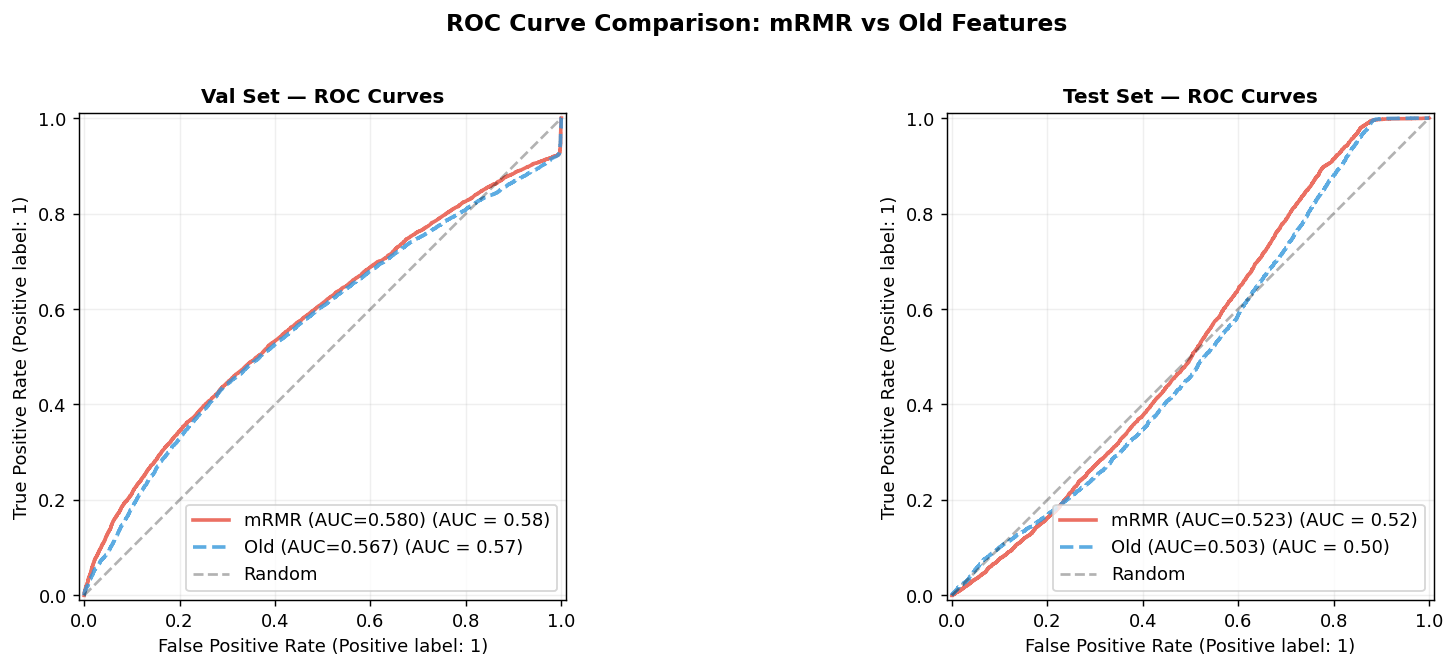

In [38]:
# ============================================================
# 4.3  ROC curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split_name in [(axes[0], 'Val'), (axes[1], 'Test')]:
    for results, name, color, ls in [
        (results_mrmr, 'mRMR', '#E74C3C', '-'),
        (results_old, 'Old', '#3498DB', '--'),
    ]:
        r = results[split_name]
        # Use curve_kwargs to pass down line styling variables safely
        RocCurveDisplay.from_predictions(
            r['y_true'], r['y_prob'],
            name=f"{name} (AUC={r['roc_auc']:.3f})",
            ax=ax,
            curve_kwargs={
                'linewidth': 2,
                'linestyle': ls,
                'alpha': 0.8,
                'color': color  # Put your custom colors to work here!
            }
        )
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    ax.set_title(f'{split_name} Set — ROC Curves')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.2)

plt.suptitle('ROC Curve Comparison: mRMR vs Old Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('logreg_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

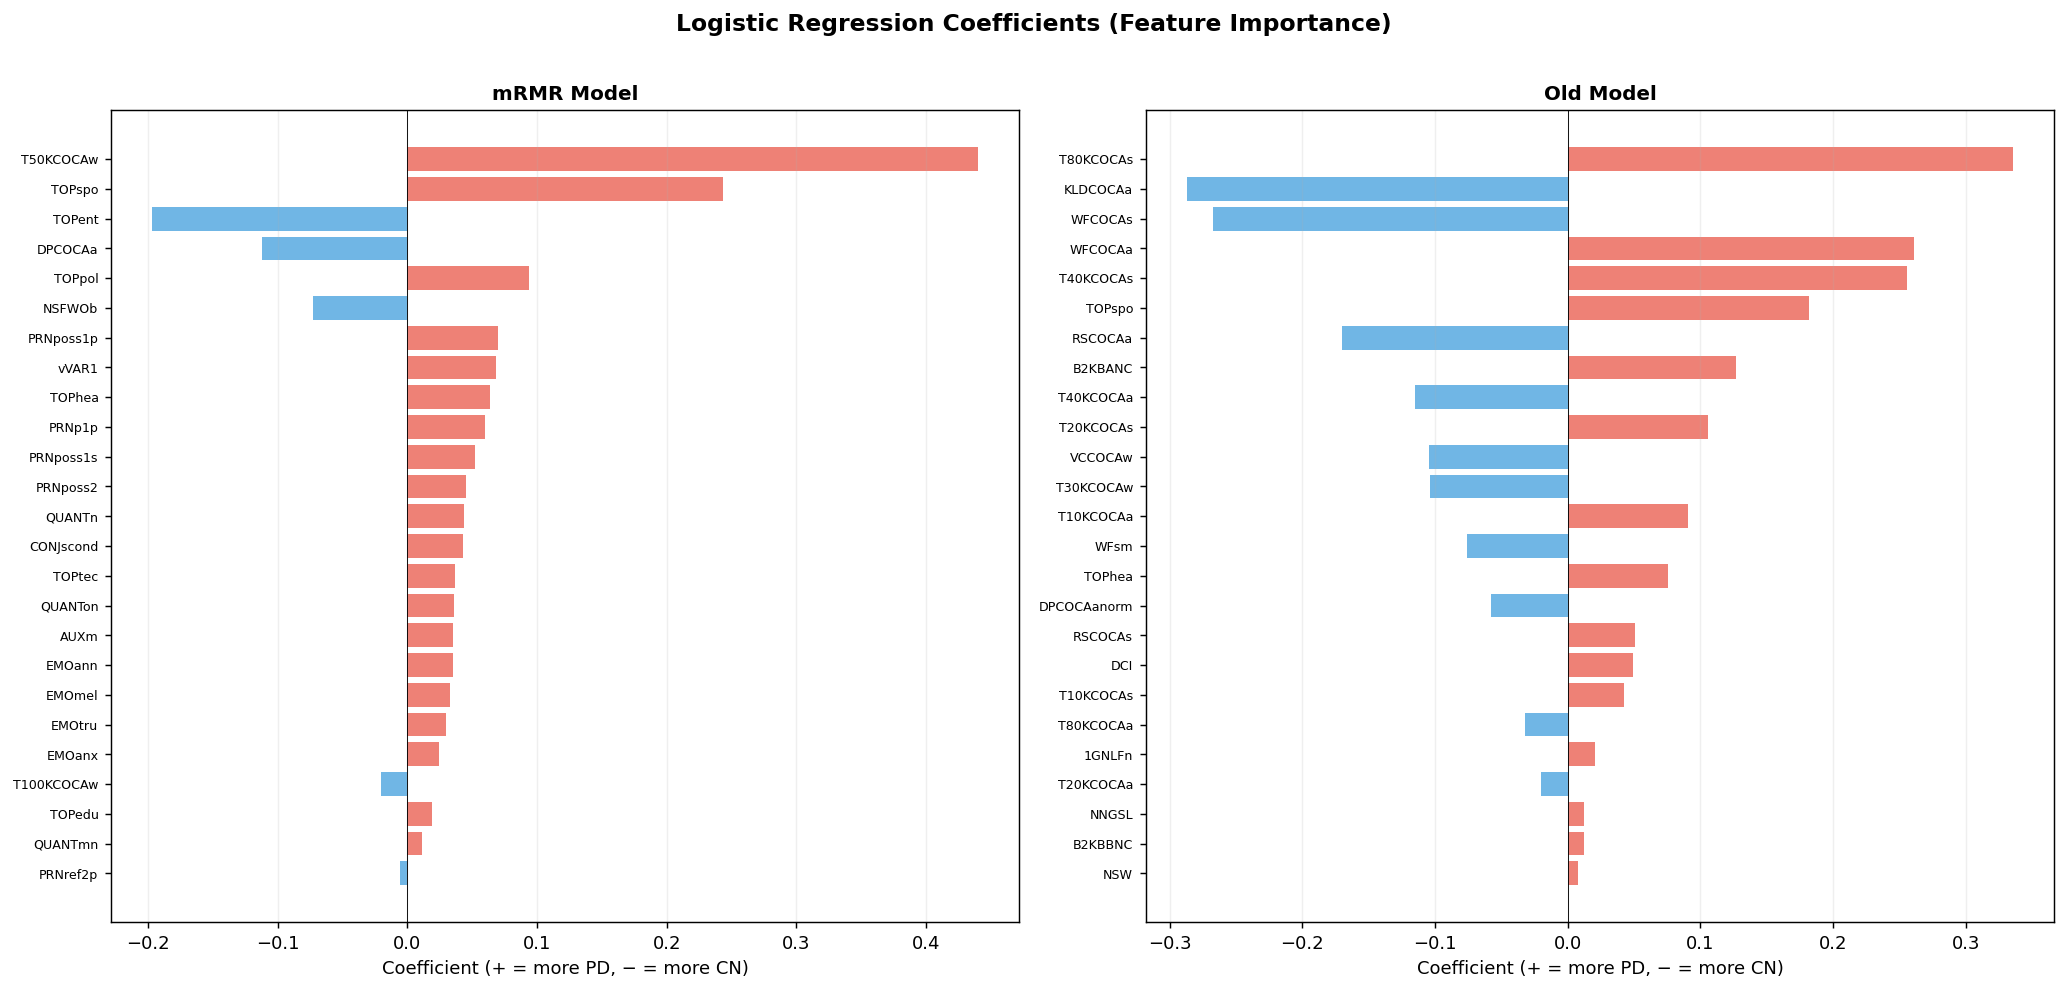

In [39]:
# ============================================================
# 4.4  Feature importance (logistic regression coefficients)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(mrmr_features) * 0.3)))

for ax, model, features, title in [
    (axes[0], model_mrmr, mrmr_features, 'mRMR Model'),
    (axes[1], model_old, old_features, 'Old Model'),
]:
    coefs = model.coef_[0]
    sorted_idx = np.argsort(np.abs(coefs))[::-1]
    
    sorted_feats = [features[i] for i in sorted_idx]
    sorted_coefs = coefs[sorted_idx]
    
    colors = ['#E74C3C' if c > 0 else '#3498DB' for c in sorted_coefs]
    ax.barh(range(len(sorted_feats)), sorted_coefs, color=colors, alpha=0.7)
    ax.set_yticks(range(len(sorted_feats)))
    ax.set_yticklabels(sorted_feats, fontsize=7)
    ax.set_xlabel('Coefficient (+ = more PD, − = more CN)')
    ax.set_title(title)
    ax.invert_yaxis()
    ax.axvline(0, color='black', lw=0.5)
    ax.grid(axis='x', alpha=0.2)

plt.suptitle('Logistic Regression Coefficients (Feature Importance)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('logreg_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5 — Per-subject accuracy

Since each subject has many utterances, let's also check:  
if we take a **majority vote** across all utterances from one subject,  
how often do we classify the subject correctly?

In [40]:
# ============================================================
# 5.  Subject-level majority vote
# ============================================================

def subject_level_eval(df_split, features, model, scaler, split_name):
    """Aggregate utterance predictions to subject level via majority vote."""
    X = df_split[features].fillna(df_split[features].median())
    X_scaled = scaler.transform(X)
    
    df_split = df_split.copy()
    df_split['pred'] = model.predict(X_scaled)
    df_split['prob'] = model.predict_proba(X_scaled)[:, 1]
    
    # Majority vote per subject
    subj_results = df_split.groupby('subject').agg(
        true_label=('label', 'first'),
        mean_prob=('prob', 'mean'),
        vote_pred=('pred', lambda x: int(x.mean() >= 0.5)),
        n_utterances=('pred', 'count'),
        pct_pred_pd=('pred', 'mean'),
    ).reset_index()
    
    subj_acc = accuracy_score(subj_results['true_label'], subj_results['vote_pred'])
    subj_f1 = f1_score(subj_results['true_label'], subj_results['vote_pred'])
    subj_auc = roc_auc_score(subj_results['true_label'], subj_results['mean_prob'])
    
    return subj_results, subj_acc, subj_f1, subj_auc


print('Subject-Level Results (majority vote across utterances)')
print('=' * 70)
print(f'{"":<20s} {"mRMR":>20s}     {"Old":>20s}')
print(f'{"":<20s} {"Acc / F1 / AUC":>20s}     {"Acc / F1 / AUC":>20s}')
print('─' * 70)

for split_name, sdf in [('Val', val_df), ('Test', test_df)]:
    _, acc_m, f1_m, auc_m = subject_level_eval(sdf, mrmr_features, model_mrmr, scaler_mrmr, split_name)
    _, acc_o, f1_o, auc_o = subject_level_eval(sdf, old_features, model_old, scaler_old, split_name)
    
    print(f'{split_name:<20s} {acc_m:.3f} / {f1_m:.3f} / {auc_m:.3f}     '
          f'{acc_o:.3f} / {f1_o:.3f} / {auc_o:.3f}')

Subject-Level Results (majority vote across utterances)
                                     mRMR                      Old
                           Acc / F1 / AUC           Acc / F1 / AUC
──────────────────────────────────────────────────────────────────────
Val                  0.800 / 0.750 / 0.750     0.550 / 0.571 / 0.750
Test                 0.700 / 0.667 / 0.792     0.600 / 0.600 / 0.750


In [41]:
# ============================================================
# 5.2  Per-subject prediction detail (test set, mRMR model)
# ============================================================
subj_detail, _, _, _ = subject_level_eval(
    test_df, mrmr_features, model_mrmr, scaler_mrmr, 'Test'
)

print('Per-subject detail (Test set, mRMR model):')
print(f'{"Subject":<12s} {"True":>6s} {"Pred":>6s} {"Correct":>8s} {"Avg P(PD)":>10s} {"Utterances":>11s} {"% pred PD":>10s}')
print('─' * 65)
for _, row in subj_detail.sort_values('subject').iterrows():
    true_label = 'PD' if row['true_label'] == 1 else 'CN'
    pred_label = 'PD' if row['vote_pred'] == 1 else 'CN'
    correct = '✓' if true_label == pred_label else '✗'
    print(f'{row["subject"]:<12s} {true_label:>6s} {pred_label:>6s} {correct:>8s} '
          f'{row["mean_prob"]:>10.3f} {row["n_utterances"]:>11.0f} {row["pct_pred_pd"]:>9.0%}')

Per-subject detail (Test set, mRMR model):
Subject        True   Pred  Correct  Avg P(PD)  Utterances  % pred PD
─────────────────────────────────────────────────────────────────
cn_08            CN     CN        ✓      0.483         563       44%
cn_15            CN     PD        ✗      0.506        2348       54%
cn_29            CN     PD        ✗      0.570        2088       75%
cn_39            CN     CN        ✓      0.486        1020       43%
cn_43            CN     CN        ✓      0.154         571        0%
cn_52            CN     CN        ✓      0.356         810       27%
pd_07            PD     PD        ✓      0.523        2348       59%
pd_08            PD     PD        ✓      0.547         804       66%
pd_14            PD     CN        ✗      0.489        4809       41%
pd_35            PD     PD        ✓      0.526         837       63%


---
## 6 — Full classification report

In [42]:
# ============================================================
# 6.  Detailed classification reports
# ============================================================
print('Detailed Classification Report — mRMR Model (Test Set)')
print('=' * 55)
r = results_mrmr['Test']
print(classification_report(r['y_true'], r['y_pred'],
                            target_names=['CN', 'PD']))

print('\nDetailed Classification Report — Old Model (Test Set)')
print('=' * 55)
r = results_old['Test']
print(classification_report(r['y_true'], r['y_pred'],
                            target_names=['CN', 'PD']))

Detailed Classification Report — mRMR Model (Test Set)
              precision    recall  f1-score   support

          CN       0.46      0.50      0.48      7400
          PD       0.54      0.50      0.52      8798

    accuracy                           0.50     16198
   macro avg       0.50      0.50      0.50     16198
weighted avg       0.50      0.50      0.50     16198


Detailed Classification Report — Old Model (Test Set)
              precision    recall  f1-score   support

          CN       0.44      0.44      0.44      7400
          PD       0.53      0.54      0.54      8798

    accuracy                           0.49     16198
   macro avg       0.49      0.49      0.49     16198
weighted avg       0.49      0.49      0.49     16198



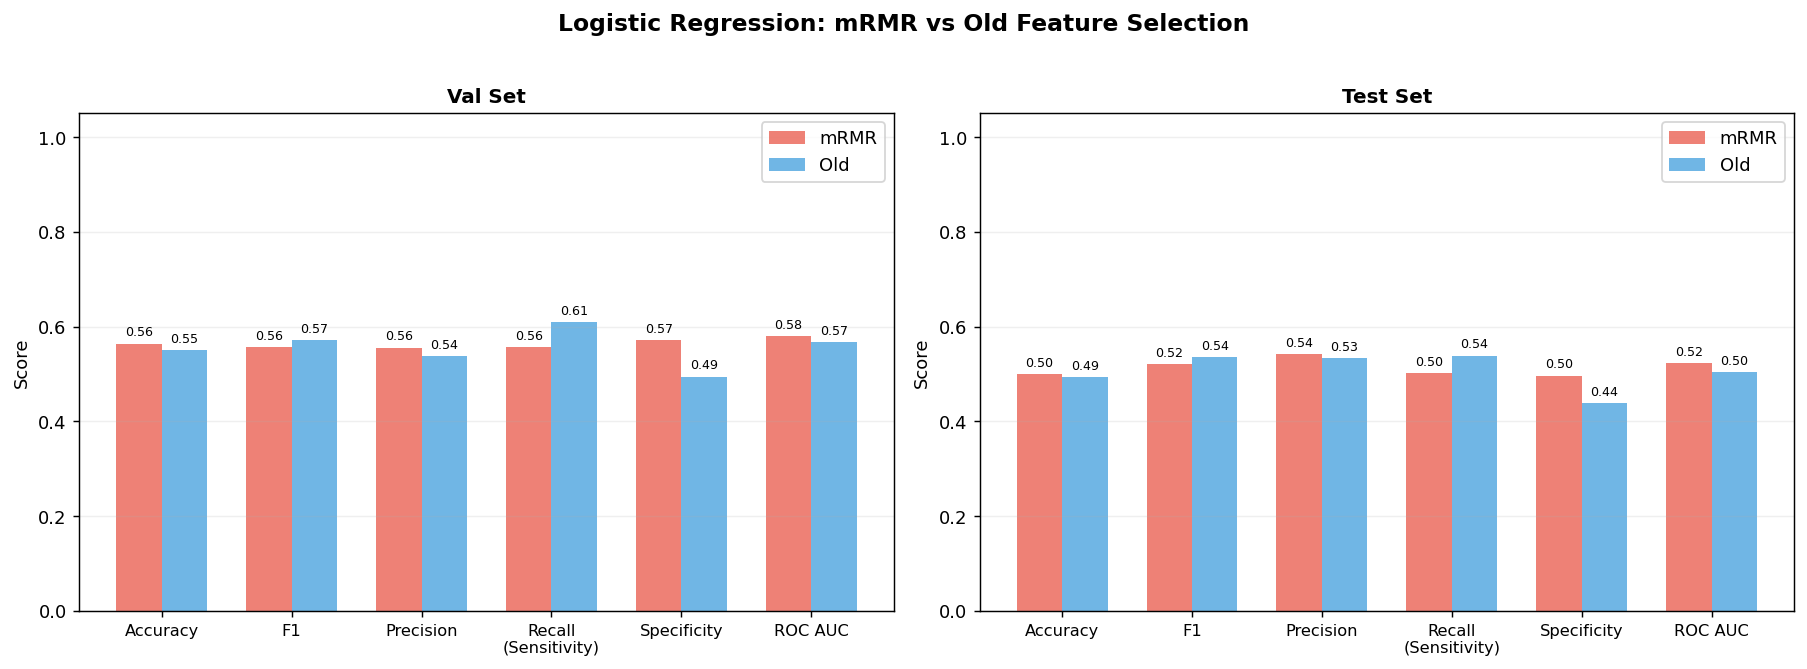

In [43]:
# ============================================================
# 7.  Summary comparison bar chart
# ============================================================
metrics_to_plot = ['accuracy', 'f1', 'precision', 'recall', 'specificity', 'roc_auc']
metric_labels = ['Accuracy', 'F1', 'Precision', 'Recall\n(Sensitivity)', 'Specificity', 'ROC AUC']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split_name in [(axes[0], 'Val'), (axes[1], 'Test')]:
    x = np.arange(len(metrics_to_plot))
    width = 0.35
    
    mrmr_vals = [results_mrmr[split_name][m] for m in metrics_to_plot]
    old_vals = [results_old[split_name][m] for m in metrics_to_plot]
    
    bars1 = ax.bar(x - width/2, mrmr_vals, width, label='mRMR', color='#E74C3C', alpha=0.7)
    bars2 = ax.bar(x + width/2, old_vals, width, label='Old', color='#3498DB', alpha=0.7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(f'{split_name} Set')
    ax.legend()
    ax.grid(axis='y', alpha=0.2)
    
    # Add value labels
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Logistic Regression: mRMR vs Old Feature Selection',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('logreg_comparison_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# ============================================================
# 8.  Evaluate both models on ALL 100 subjects
# ============================================================

print('FULL DATASET EVALUATION (all subjects, subject-level majority vote)')
print('=' * 70)

for model, scaler, features, name in [
    (model_mrmr, scaler_mrmr, mrmr_features, 'mRMR'),
    (model_old, scaler_old, old_features, 'Old'),
]:
    X_all = df[features].fillna(df[features].median())
    X_all_scaled = scaler.transform(X_all)

    df_eval = df[['subject', 'group', 'label']].copy()
    df_eval['pred'] = model.predict(X_all_scaled)
    df_eval['prob'] = model.predict_proba(X_all_scaled)[:, 1]

    subj = df_eval.groupby('subject').agg(
        true_label=('label', 'first'),
        group=('group', 'first'),
        mean_prob=('prob', 'mean'),
        vote_pred=('pred', lambda x: int(x.mean() >= 0.5)),
        n_utterances=('pred', 'count'),
        pct_pred_pd=('pred', 'mean'),
    ).reset_index()

    acc = accuracy_score(subj['true_label'], subj['vote_pred'])
    f1 = f1_score(subj['true_label'], subj['vote_pred'])
    auc = roc_auc_score(subj['true_label'], subj['mean_prob'])
    sens = recall_score(subj['true_label'], subj['vote_pred'])
    spec = recall_score(subj['true_label'], subj['vote_pred'], pos_label=0)

    print(f'\n  {name} Model — {len(subj)} subjects')
    print(f'    Accuracy    : {acc:.3f}')
    print(f'    F1          : {f1:.3f}')
    print(f'    Sensitivity : {sens:.3f}  (PD correctly identified)')
    print(f'    Specificity : {spec:.3f}  (CN correctly identified)')
    print(f'    ROC AUC     : {auc:.3f}')

    # Show every subject
    print(f'\n    {"Subject":<12s} {"True":>6s} {"Pred":>6s} {"OK":>4s} {"P(PD)":>7s} {"Utts":>6s} {"%PD":>5s}  {"Split":>6s}')
    print(f'    {"─"*12} {"─"*6} {"─"*6} {"─"*4} {"─"*7} {"─"*6} {"─"*5}  {"─"*6}')

    for _, row in subj.sort_values('subject').iterrows():
        true = 'PD' if row['true_label'] == 1 else 'CN'
        pred = 'PD' if row['vote_pred'] == 1 else 'CN'
        ok = '✓' if true == pred else '✗'
        # Show which split this subject was in
        split = 'train' if row['subject'] in train_subjects else \
                'val' if row['subject'] in val_subjects else \
                'test' if row['subject'] in test_subjects else '?'
        print(f'    {row["subject"]:<12s} {true:>6s} {pred:>6s} {ok:>4s} {row["mean_prob"]:>7.3f} '
              f'{row["n_utterances"]:>6.0f} {row["pct_pred_pd"]:>4.0%}  {split:>6s}')

    # Misclassified subjects
    wrong = subj[subj['true_label'] != subj['vote_pred']]
    print(f'\n    Misclassified: {len(wrong)}/{len(subj)} subjects')

FULL DATASET EVALUATION (all subjects, subject-level majority vote)

  mRMR Model — 100 subjects
    Accuracy    : 0.750
    F1          : 0.706
    Sensitivity : 0.750  (PD correctly identified)
    Specificity : 0.750  (CN correctly identified)
    ROC AUC     : 0.780

    Subject        True   Pred   OK   P(PD)   Utts   %PD   Split
    ──────────── ────── ────── ──── ─────── ────── ─────  ──────
    cn_01            CN     PD    ✗   0.521   1568  61%   train
    cn_02            CN     CN    ✓   0.490   2520  49%   train
    cn_03            CN     CN    ✓   0.480    839  38%     val
    cn_04            CN     CN    ✓   0.482    965  40%   train
    cn_05            CN     PD    ✗   0.575   1514  76%   train
    cn_06            CN     CN    ✓   0.496   1144  50%   train
    cn_07            CN     CN    ✓   0.476   3298  38%   train
    cn_08            CN     CN    ✓   0.483    563  44%    test
    cn_09            CN     CN    ✓   0.491   2210  47%   train
    cn_10            C

---
## Summary

### What we did
1. Split data by **subject** (70/20/10) so no subject appears in multiple splits
2. Trained logistic regression with **balanced class weights** (handles CN/PD imbalance)
3. Evaluated on both **utterance level** and **subject level** (majority vote)
4. Compared **mRMR features** vs **old features**

### Key metrics to report
- **Accuracy:** overall correctness
- **F1 score:** harmonic mean of precision and recall (good for imbalanced data)
- **Sensitivity (recall):** what fraction of actual PD cases did we catch?
- **Specificity:** what fraction of actual CN cases did we correctly identify?
- **ROC AUC:** overall discriminative ability (0.5 = random, 1.0 = perfect)

### What to watch out for
- **Train >> Val/Test:** overfitting — model memorised training data
- **Val >> Test:** your validation set was too easy or too small
- **High recall, low specificity (or vice versa):** model is biased toward one class
- **Subject-level accuracy:** more meaningful than utterance-level for clinical applications

### Next steps
- Try other models: Random Forest, SVM, Gradient Boosting
- Try regularisation tuning (C parameter in logistic regression)
- Try cross-validation instead of a single split (more robust with small n)
- Combine CYMO linguistic features with acoustic features from earlier notebooks